In [1]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

DATASET_PATH = Path(
    r"D:\andrew assignment\Image Processing assignment\dataset"
)

CLASS_NAMES = [
    "Unripe",
    "Partially Ripe",
    "Ripe"
]

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
}

# Use the same image size across the experiment
IMAGE_SIZE = (224, 224)

# Hybrid Pipeline parameters
CLAHE_CLIP_LIMIT = 1.0
S_MIN = 20
KERNEL_SIZE = 7
MORPH_ITERATIONS = 2

print("Dataset exists:", DATASET_PATH.exists())

Dataset exists: True


In [3]:
def extract_hybrid_features(image):

    # =====================================================
    # 1. Resize
    # =====================================================

    resized = cv2.resize(
        image,
        IMAGE_SIZE
    )

    # =====================================================
    # 2. Convert to HSV
    # =====================================================

    hsv = cv2.cvtColor(
        resized,
        cv2.COLOR_BGR2HSV
    )

    h, s, v = cv2.split(hsv)

    # =====================================================
    # 3. CLAHE Enhancement on V Channel
    # =====================================================

    clahe = cv2.createCLAHE(
        clipLimit=CLAHE_CLIP_LIMIT,
        tileGridSize=(8, 8)
    )

    v_enhanced = clahe.apply(v)

    enhanced_hsv = cv2.merge([
        h,
        s,
        v_enhanced
    ])

    # =====================================================
    # 4. HSV Thresholding
    # =====================================================

    lower_hsv = np.array([
        0,
        S_MIN,
        20
    ])

    upper_hsv = np.array([
        179,
        255,
        255
    ])

    threshold_mask = cv2.inRange(
        enhanced_hsv,
        lower_hsv,
        upper_hsv
    )

    # =====================================================
    # 5. Initial Contour Detection
    # =====================================================

    contours, _ = cv2.findContours(
        threshold_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return None

    largest_contour = max(
        contours,
        key=cv2.contourArea
    )

    # =====================================================
    # 6. Create Mango Mask
    # =====================================================

    mango_mask = np.zeros(
        resized.shape[:2],
        dtype=np.uint8
    )

    cv2.drawContours(
        mango_mask,
        [largest_contour],
        -1,
        255,
        thickness=cv2.FILLED
    )

    # =====================================================
    # 7. Morphological Closing
    # =====================================================

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (KERNEL_SIZE, KERNEL_SIZE)
    )

    clean_mask = cv2.morphologyEx(
        mango_mask,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=MORPH_ITERATIONS
    )

    # =====================================================
    # 8. Recalculate Final Contour
    # =====================================================

    final_contours, _ = cv2.findContours(
        clean_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(final_contours) == 0:
        return None

    final_contour = max(
        final_contours,
        key=cv2.contourArea
    )

    # =====================================================
    # 9. HSV Histogram Colour Features
    # =====================================================

    hist_h = cv2.calcHist(
        [enhanced_hsv],
        [0],
        clean_mask,
        [32],
        [0, 180]
    )

    hist_s = cv2.calcHist(
        [enhanced_hsv],
        [1],
        clean_mask,
        [32],
        [0, 256]
    )

    hist_v = cv2.calcHist(
        [enhanced_hsv],
        [2],
        clean_mask,
        [32],
        [0, 256]
    )

    # Normalise histograms
    hist_h = cv2.normalize(
        hist_h,
        hist_h
    ).flatten()

    hist_s = cv2.normalize(
        hist_s,
        hist_s
    ).flatten()

    hist_v = cv2.normalize(
        hist_v,
        hist_v
    ).flatten()

    # =====================================================
    # 10. Hu Moments Shape Features
    # =====================================================

    moments = cv2.moments(
        final_contour
    )

    hu_moments = cv2.HuMoments(
        moments
    ).flatten()

    # Log scale Hu Moments
    hu_log = []

    for value in hu_moments:

        if value == 0:
            hu_log.append(0.0)

        else:
            hu_log.append(
                -np.sign(value)
                * np.log10(abs(value))
            )

    hu_log = np.array(
        hu_log
    )

    # =====================================================
    # 11. Combine Colour + Shape Features
    # =====================================================

    features = np.concatenate([
        hist_h,
        hist_s,
        hist_v,
        hu_log
    ])

    return features

In [4]:
sample_folder = DATASET_PATH / "Ripe"

sample_images = sorted([
    file
    for file in sample_folder.iterdir()
    if file.suffix.lower() in IMAGE_EXTENSIONS
])

sample_image = cv2.imread(
    str(sample_images[0])
)

sample_features = extract_hybrid_features(
    sample_image
)

print(
    "Number of features:",
    len(sample_features)
)

Number of features: 103


In [5]:
X = []
y = []

failed_images = []

for class_name in CLASS_NAMES:

    class_folder = (
        DATASET_PATH /
        class_name
    )

    class_images = sorted([
        file
        for file in class_folder.iterdir()
        if file.suffix.lower()
        in IMAGE_EXTENSIONS
    ])

    print(
        f"Processing {class_name}..."
    )

    for image_path in class_images:

        image = cv2.imread(
            str(image_path)
        )

        if image is None:

            failed_images.append(
                str(image_path)
            )

            continue

        features = extract_hybrid_features(
            image
        )

        if features is None:

            failed_images.append(
                str(image_path)
            )

            continue

        X.append(
            features
        )

        y.append(
            class_name
        )


X = np.array(X)
y = np.array(y)

print()
print("Processing completed.")
print("X shape:", X.shape)
print("y shape:", y.shape)

print(
    "Failed images:",
    len(failed_images)
)

Processing Unripe...
Processing Partially Ripe...
Processing Ripe...

Processing completed.
X shape: (750, 103)
y shape: (750,)
Failed images: 0


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Training:",
    X_train.shape
)

print(
    "Testing:",
    X_test.shape
)

Training: (600, 103)
Testing: (150, 103)


In [7]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

print(
    "Random Forest training completed."
)

Random Forest training completed.


In [8]:
y_pred = rf.predict(
    X_test
)

print(
    "Prediction completed."
)

Prediction completed.


In [9]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(
    "Hybrid Pipeline + HSV Histogram + Hu Moments"
)

print(
    "--------------------------------------------"
)

print(
    f"Accuracy : {accuracy:.4f} "
    f"({accuracy*100:.2f}%)"
)

print(
    f"Precision: {precision:.4f} "
    f"({precision*100:.2f}%)"
)

print(
    f"Recall   : {recall:.4f} "
    f"({recall*100:.2f}%)"
)

print(
    f"F1-score : {f1:.4f} "
    f"({f1*100:.2f}%)"
)

Hybrid Pipeline + HSV Histogram + Hu Moments
--------------------------------------------
Accuracy : 0.9667 (96.67%)
Precision: 0.9669 (96.69%)
Recall   : 0.9667 (96.67%)
F1-score : 0.9667 (96.67%)


In [10]:
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

                precision    recall  f1-score   support

Partially Ripe     0.9412    0.9600    0.9505        50
          Ripe     0.9796    0.9600    0.9697        50
        Unripe     0.9800    0.9800    0.9800        50

      accuracy                         0.9667       150
     macro avg     0.9669    0.9667    0.9667       150
  weighted avg     0.9669    0.9667    0.9667       150



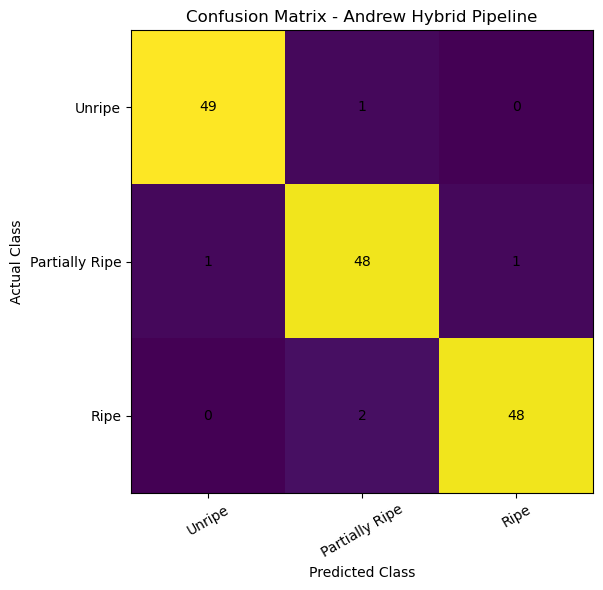

In [11]:
CLASS_ORDER = [
    "Unripe",
    "Partially Ripe",
    "Ripe"
]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=CLASS_ORDER
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.imshow(cm)

ax.set_xticks(
    range(len(CLASS_ORDER))
)

ax.set_yticks(
    range(len(CLASS_ORDER))
)

ax.set_xticklabels(
    CLASS_ORDER,
    rotation=30
)

ax.set_yticklabels(
    CLASS_ORDER
)

ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "Actual Class"
)

ax.set_title(
    "Confusion Matrix - Andrew Hybrid Pipeline"
)

for i in range(len(CLASS_ORDER)):

    for j in range(len(CLASS_ORDER)):

        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

Sample image: 288(7).JPG


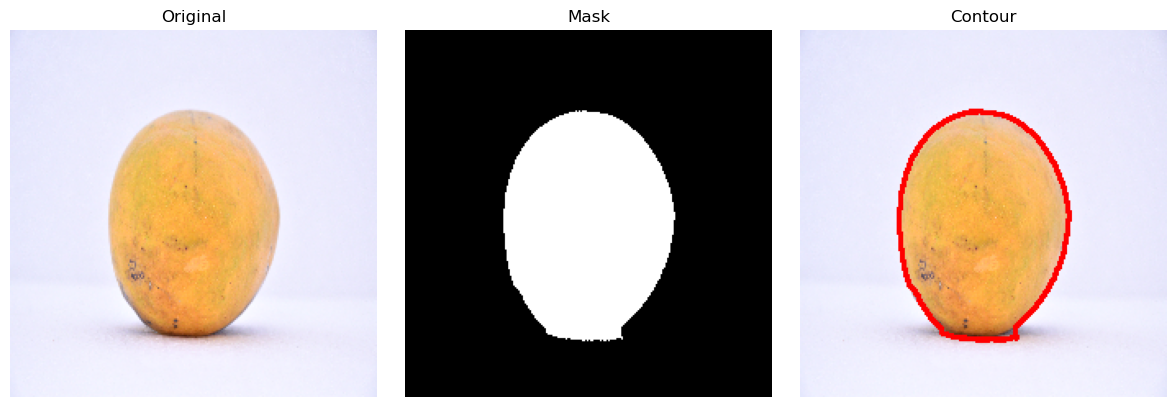

In [17]:
# ============================================================
# 3.3.4 HYBRID PIPELINE SAMPLE OUTPUT
# Remove ground shadow and keep mango only
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

IMAGE_SIZE = (224, 224)

CLAHE_CLIP_LIMIT = 1.0

# Normal segmentation threshold
S_MIN = 20

# Stronger threshold for removing grey shadow
SHADOW_REMOVAL_S_MIN = 40

KERNEL_SIZE = 7


# ------------------------------------------------------------
# Select sample image
# ------------------------------------------------------------

sample_folder = DATASET_PATH / "Ripe"

sample_images = sorted([
    file
    for file in sample_folder.iterdir()
    if file.suffix.lower() in IMAGE_EXTENSIONS
])

sample_path = sample_images[0]

image = cv2.imread(str(sample_path))

print("Sample image:", sample_path.name)


# ------------------------------------------------------------
# Resize
# ------------------------------------------------------------

resized = cv2.resize(
    image,
    IMAGE_SIZE
)


# ------------------------------------------------------------
# Convert to HSV
# ------------------------------------------------------------

hsv = cv2.cvtColor(
    resized,
    cv2.COLOR_BGR2HSV
)

h, s, v = cv2.split(hsv)


# ------------------------------------------------------------
# CLAHE enhancement on V channel
# ------------------------------------------------------------

clahe = cv2.createCLAHE(
    clipLimit=CLAHE_CLIP_LIMIT,
    tileGridSize=(8, 8)
)

v_enhanced = clahe.apply(v)

enhanced_hsv = cv2.merge([
    h,
    s,
    v_enhanced
])


# ------------------------------------------------------------
# Initial HSV segmentation
# ------------------------------------------------------------

initial_mask = cv2.inRange(
    enhanced_hsv,
    np.array([0, S_MIN, 20]),
    np.array([179, 255, 255])
)


# ------------------------------------------------------------
# Shadow removal
# Grey shadow normally has low saturation.
# Keep only sufficiently saturated pixels.
# ------------------------------------------------------------

shadow_filter = cv2.inRange(
    enhanced_hsv,
    np.array([0, SHADOW_REMOVAL_S_MIN, 20]),
    np.array([179, 255, 255])
)

cleaned_mask = cv2.bitwise_and(
    initial_mask,
    shadow_filter
)


# ------------------------------------------------------------
# Morphological closing
# Fill small holes inside mango
# ------------------------------------------------------------

kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (KERNEL_SIZE, KERNEL_SIZE)
)

cleaned_mask = cv2.morphologyEx(
    cleaned_mask,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)


# ------------------------------------------------------------
# Keep largest connected component only
# ------------------------------------------------------------

num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
    cleaned_mask,
    connectivity=8
)

if num_labels <= 1:
    raise ValueError("No mango detected.")

largest_label = 1 + np.argmax(
    stats[1:, cv2.CC_STAT_AREA]
)

final_mask = np.zeros_like(
    cleaned_mask
)

final_mask[
    labels == largest_label
] = 255


# ------------------------------------------------------------
# Final contour
# ------------------------------------------------------------

contours, _ = cv2.findContours(
    final_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

if len(contours) == 0:
    raise ValueError("No final contour detected.")

final_contour = max(
    contours,
    key=cv2.contourArea
)


# ------------------------------------------------------------
# Draw contour
# ------------------------------------------------------------

contour_result = resized.copy()

cv2.drawContours(
    contour_result,
    [final_contour],
    -1,
    (0, 0, 255),
    2
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

original_rgb = cv2.cvtColor(
    resized,
    cv2.COLOR_BGR2RGB
)

contour_rgb = cv2.cvtColor(
    contour_result,
    cv2.COLOR_BGR2RGB
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4)
)

axes[0].imshow(original_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(
    final_mask,
    cmap="gray"
)
axes[1].set_title("Mask")
axes[1].axis("off")

axes[2].imshow(contour_rgb)
axes[2].set_title("Contour")
axes[2].axis("off")

plt.tight_layout()
plt.show()

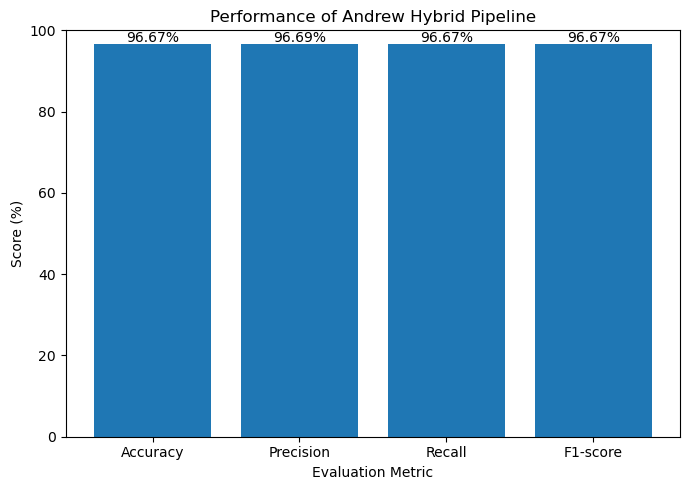

In [18]:
import matplotlib.pyplot as plt

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

scores = [
    96.67,
    96.69,
    96.67,
    96.67
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    metrics,
    scores
)

plt.ylim(0, 100)
plt.ylabel("Score (%)")
plt.xlabel("Evaluation Metric")

plt.title(
    "Performance of Andrew Hybrid Pipeline"
)

for bar, value in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [19]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

                precision    recall  f1-score   support

Partially Ripe     0.9412    0.9600    0.9505        50
          Ripe     0.9796    0.9600    0.9697        50
        Unripe     0.9800    0.9800    0.9800        50

      accuracy                         0.9667       150
     macro avg     0.9669    0.9667    0.9667       150
  weighted avg     0.9669    0.9667    0.9667       150



In [20]:
from sklearn.metrics import confusion_matrix

CLASS_ORDER = [
    "Unripe",
    "Partially Ripe",
    "Ripe"
]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=CLASS_ORDER
)

print(cm)

[[49  1  0]
 [ 1 48  1]
 [ 0  2 48]]


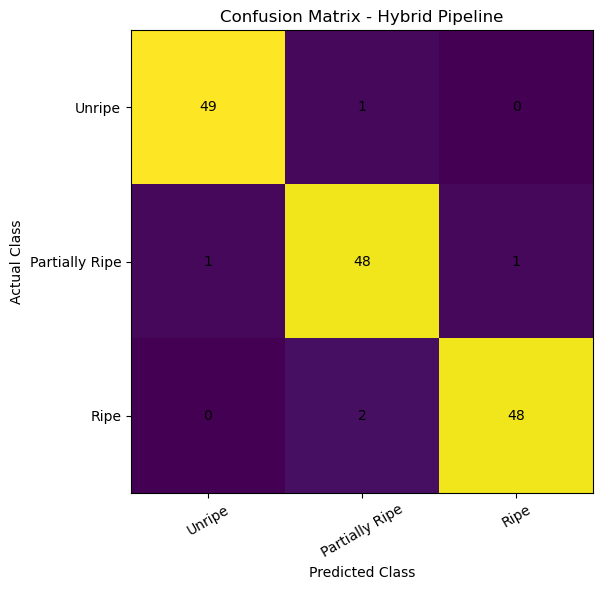

In [21]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.imshow(cm)

ax.set_xticks(
    range(len(CLASS_ORDER))
)

ax.set_yticks(
    range(len(CLASS_ORDER))
)

ax.set_xticklabels(
    CLASS_ORDER,
    rotation=30
)

ax.set_yticklabels(
    CLASS_ORDER
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

ax.set_title(
    "Confusion Matrix - Hybrid Pipeline"
)

for i in range(len(CLASS_ORDER)):
    for j in range(len(CLASS_ORDER)):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()